Исследование проведено на материале проекта «Пишу тебе»:
Использованы данные Цифрового корпуса почтовых открыток «Пишу тебе». URL: https://pishutebe.ru/

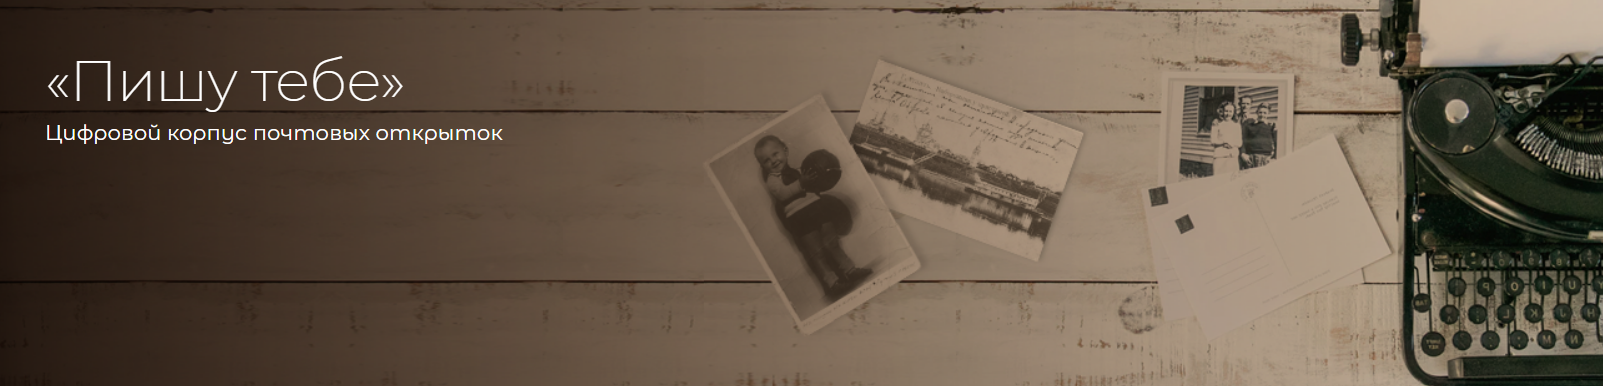

# Введение в проблему

В процессе работы с корпусом мы заметили, что в текстах открыток есть неразборчивые слова, которые отмечены как [нрзб]. Причиной этому может стать плохая сохранность открыток или непонятный почерк.

Так, решение задачи автоматического заполнения пропусков в почтовых открыток имеет несколько важных научных и практических аспектов.

Во-первых, подобные тексты представляют собой уникальный лингвистический материал, отражающий особенности письменной коммуникации и культурно-исторические ценности людей. Пропуски нарушают целостность текстов и затрудняют их качественный корпусный анализ.

Во-вторых, корпус, которых появился недавно, не имеет большого объема, поэтому каждый текст открытки имеет большую ценность, и заполнение пропусков в нем позволит повысить количество полных и точных текстов открыток.

В-третьих, почтовые открытки - новый материал, к которому почти не применялись методы обработки естественного языка. Обучение и оценка моделей на текстах почтовой переписки способствует развитию и улучшению данных алгоритмов для дальнейшего применения в русском языке.

# Краткий исторический обзор решения проблемы

**Ранние подходы: n-граммовые модели**

Первые успешные методы предсказания слова базировались на статистических n-граммовых языковых моделях. Такие модели оценивают вероятность появления слова на основе частоты его сочетания с предыдущими (или последующими) словами в корпусе текстов.

*Преимущества:* простота реализации и интерпретируемость результатов. Они позволяли достигать довольно высокой точности на небольших данных.

*Недостатки:* невозможность учитывать длинные зависимости, высокая чувствительность к редким и новым словам, а также необходимость применения методов сглаживания вероятностей для борьбы с нулевыми частотами.

Эти ограничения обусловили поиск более совершенных методов.

**Векторные представления слов (word embeddings)**

С развитием машинного обучения появились методы, представляющие слова в виде векторов, которые отражают их семантическую близость. Модели Word2Vec, GloVe и их аналоги позволили учитывать не только частоты, но и смысловые связи между словами.

*Преимущества:* метод дает возможность работать с редкими словами и учитывать семантические связи между словами.

*Недостатки:* ограниченность контекста и отсутствие учёта порядка слов в длинных предложениях.

**Нейросетевые модели**

Потом стали применять нейронные сети: сначала простые полносвязные, затем рекуррентные (RNN, LSTM, GRU), которые позволили моделировать более длинные зависимости в тексте. Однако и эти модели сталкивались с проблемами затухания градиента, сложности обучения и ограниченности контекста.

**Современные методы: LLM**

Уже обученные на большом объеме данных, архитектуры Transformer глубоко понимают семантику текста, а также могут быть дообучены на специализированных корпусах.

# SOTA-алгоритм

**Ссылка на статью:** https://arxiv.org/pdf/2309.10931

**Сылка на HuggingFace:** https://huggingface.co/ai-forever/ruRoberta-large

**RuRoberta-large** — первая RoBERTa-модель, обученная исключительно на современных русскоязычных текстах.

**Архитектура модели RuRoberta-large**

Базовая архитектура: RuRoberta-large — это реализация архитектуры RoBERTa для русского языка. RoBERTa — это улучшенная версия BERT, где убраны задачи NSP (Next Sentence Prediction), увеличен размер батча, изменён способ маскировки и увеличено количество обучающих данных.

Параметры RuRoberta-large:

*   24 слоя (transformer layers)
*   1024 скрытых нейрона (hidden size)
*   16 голов внимания (attention heads)
*   355 миллионов параметров

Важные особенности модели:

1. Токенизация: используется SentencePiece с размером словаря 50 000 токенов, что важно для морфологически богатого русского языка.

2. Masked Language Modeling: модель обучалась на задаче восстановления замаскированных токенов (fill-mask).

3. Датасет для обучения Объем: Более 200 ГБ чистого текста, что составляет примерно 30 миллиардов токенов.

4. Источники: Современные русскоязычные тексты из интернета: новостные сайты, Википедия, книги, форумы и другие открытые источники.

5. Качество: Данные тщательно очищались: удалялись некачественные, нерелевантные, дублирующиеся и нерусскоязычные тексты.

6. Особенность: В отличие от многих других моделей, RuRoberta обучалась исключительно на современных русских текстах, что обеспечивает её актуальность для современных задач.

---
**Токенизация:** используется SentencePiece с размером словаря 50 000 токенов, что важно для морфологически богатого русского языка.


**Датасет для обучения**

Объем: более 200 ГБ чистого текста, что составляет примерно 30 миллиардов токенов.

Источники: Современные русскоязычные тексты из интернета: новостные сайты, Википедия, книги, форумы и другие открытые источники.


---
**Особенности:**
1. RuRoberta обучалась именно на современных русских текстах.
2. модель обучалась на задаче восстановления замаскированных токенов (fill-mask).

"Our models are pretrained using the masked language modeling (MLM) objective, where a portion of the input tokens are randomly masked and the model learns to predict these masked tokens based on the context."

**Сравнение с другими моделями**

В статье RuRoberta-large с помощью метрики F1-score сравнивается с:

RuBERT (DeepPavlov)

Multilingual BERT (mBERT)

XLM-RoBERTa (многоязычная)

RuGPT-3 (генеративная)

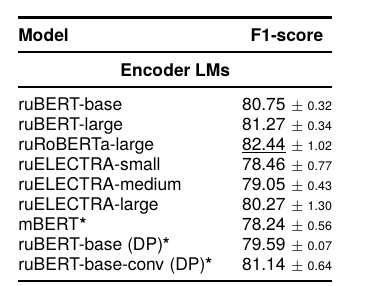

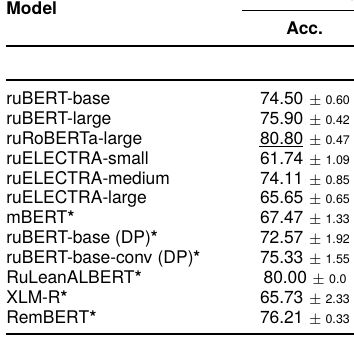

**Результаты:**

RuRoberta-large стабильно превосходит конкурентов по точности на большинстве задач.

1. Особенно заметен прирост на задачах, где требуется глубокое понимание контекста и морфологии русского языка.

"The extensive pretraining on a large and clean Russian corpus enables RuRoBERTa-large to better capture the morphological and syntactic nuances of the Russian language, which is reflected in its superior performance in word prediction tasks."

2. В задаче masked word prediction (fill-mask) RuRoberta-large показывает лучшие результаты среди всех моделей, участвовавших в сравнении.

"RuRoBERTa-large achieves state-of-the-art results on a wide range of Russian NLP benchmarks, outperforming previous models such as RuBERT, mBERT, and XLM-R, especially in tasks requiring deep contextual understanding like masked language modeling."

**Вывод:** RuRoberta-large — это самая современная (SOTA) языковая модель *для русского языка*, построенная по архитектуре RoBERTa и обученная на крупнейшем корпусе современных русскоязычных текстов. Она превосходит все существующие аналоги в задаче предсказания пропущенных слов (word prediction), что подтверждено на ряде открытых бенчмарков. Модель доступна для использования через Hugging Face и идеально подходит для задач дополнения русских текстов.

# Необходимые библиотеки

In [ ]:
import numpy as np
import pandas as pd #работа с числовыми таблицами и временными рядами
import matplotlib.pyplot as plt #визуализация (графики)
import scipy #пакет прикладных математических процедур
import scipy.stats as stats #статистические функции/критерии
import seaborn as sns #статистические графики
import math #математические операции с числами
sns.set()

# Описание набора данных, процедуры первичного анализа и подготовки набора данных к решению задачи.

1. Номер открытки - уникальный номер открытки, по которому ее можно найти в базе
2. Лицевая сторона - ссылка на отсканированное изображение лицевой стороны открытки
3. Оборотная сторона - сылка на отсканированное изображение оборотной стороны открытки
4. Язык текста открытки - язык, на котором адресант написал текст
5. Текст открытки - расшифрованный текст адресанта
6. Перевод текста открытки - перевод на русский язык текста адресанта, написанного на иностранном языке
7. Вид орфографии - латиница, дореволюционная, современная
8. Дата написания текста - при явном указании автора (не штемпель). “xx” указывает либо на отсутствие (части) даты, либо на невозможность расшифровки
9. Адрес отправителя
10. Имя отправителя
11. Адрес получателя
12. Индекс получателя
13. Имя получателя
14. Дата открытки со штемпеля (место отправления) - по месту отправления
15. Дата открытки со штемпеля (место, куда открытка прибыла) - по месту получения
16. Тип изображения - фотография, рисунок, картина, другое
17. Описание изображения - информация об изображении, напечатанная издателем открытки: автор, год фотографии, картины или рисунка. Разметчик не описывает изображение самостоятельно, а фиксирует только то, что напечатано.
18. Дата печати открытки
19. Описание открытки - описание извлекается из напечатанных на открытке сведений: издательство, цена открытки и другая метаинформация
20. Дополнительные сведения об отправителе - формы титулования (Его Высокоблагородие, Высокородие  т.д.), родственные связи (мать, отец, сестра и т.д.) и род занятий, если есть прямое указание (гимназист, учитель и т.д.)
21. Дополнительные сведения о получателе
Формы титулования (Его Высокоблагородие, Высокородие  т.д.), родственные связи (мать, отец, сестра и т.д.) и род занятий, если есть прямое указание (гимназист, учитель и т.д.)
22. Период дореволюционный, советский или постсоветский
21. Дата открытки (нормализованная) - дата для поиска и сортировки, обобщенная на основе всех полей с датами
22. Страна - место отправления
23. Населенный пункт - место отправления
24. Страна - место получения
25. Населенный пункт место получения
26. Теги

In [ ]:
df = pd.read_csv('/content/[2024.10.07] Пишу тебе. Корпус (база 1-5, 7-9, 12) - [2024.10.07] Пишу тебе. Корпус (база 1-5, 7-9, 12).csv')

In [ ]:
df.head()

,Номер открытки,Лицевая сторона - ссылка,Оборотная сторона - ссылка,Язык текста открытки,Текст открытки,Перевод текста открытки (если на иностранном языке),Вид орфографии,"Дата написания текста (если автор указал явно, не штемпели)",Адрес отправителя,Имя отправителя,...,Населенный пункт (откуда),Страна (куда),Населенный пункт (куда),Тег_1,Тег_2,Тег_3,Тег_4,Тег_5,Тег_6,Тег_7
0,50,https://storage.yandexcloud.net/postcards-resi...,https://storage.yandexcloud.net/postcards-resi...,русский,"{Милый Жоржик! Простите, голубчик, за молчание...",NaN,"Дореволюционная (ъ,ѣ и т.д.)",[отсутствует],г. Одесса,[отсутствует],...,"Херсонская губерния, Одесский уезд, г. Одесса",Российская Империя,"Тифлисская губерния, Тифлисский уезд, г. Тифлис",Шлю привет,Житейское,Дурные вести,Учеба,"Простите, что долго не писал",NaN,NaN
1,51,https://storage.yandexcloud.net/postcards-resi...,https://storage.yandexcloud.net/postcards-resi...,русский,Добрейший Паша! Будь добр вышли мне на консерв...,NaN,"Дореволюционная (ъ,ѣ и т.д.)",xx.xx.xxxx,Москва,М.Каневски,...,"Московская губерния, Московский уезд, г. Москва",Российская Империя,"Область Войска Донского, Ростовский уезд, г. Р...",Просьба,Рассказ об искусстве,Шлю привет,NaN,NaN,NaN,NaN
2,52,https://storage.yandexcloud.net/postcards-resi...,https://storage.yandexcloud.net/postcards-resi...,русский,Милая моя Олечка! Открытку твою получила. Спас...,NaN,"Дореволюционная (ъ,ѣ и т.д.)",07.12.1910,Одесса,[отсутствует],...,"Херсонская губерния, Одесский уезд, г. Одесса",Российская Империя,"Тифлисская губерния, Тифлисский уезд, г. Тифлис",Новости,Житейское,Дурные вести,Письма от семьи,Письма от мамы,Шлю привет,NaN
3,67,https://storage.yandexcloud.net/postcards-resi...,https://storage.yandexcloud.net/postcards-resi...,немецкий,Odessa. 30. 7. 01. Herzliche Grüße von [?M.Cho...,Сердечный привет от [?М. Холоденко],Латиница/дореволюционная,30.07.1901,Одесса,[?M.Cholodenko] [Перевод] [?М. Холоденко],...,г. Одесса,Германия,"Саксония, г. Дрезден",Шлю привет,Иностранный язык,NaN,NaN,NaN,NaN,NaN
4,68,https://storage.yandexcloud.net/postcards-resi...,https://storage.yandexcloud.net/postcards-resi...,иностранный язык,[отсутствует],NaN,Латиница,[отсутствует],[отсутствует],[отсутствует],...,[отсутствует],[отсутствует],[отсутствует],NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(45740, 34)

Корпус содержит 45 740 открыток, каждая из которых характеризуется 34 признаками. Открытки охватывают различные временные периоды и представлены на нескольких языках. В рамках данного исследования мы сосредоточимся исключительно на постсоветских открытках, что обусловлено отсутствием архаичных орфографических особенностей, которые помешали бы машинному обучению,а также
необходимостью анализа именно современного русского языка.

In [ ]:
df_copy = df.copy()

## Период

Выберем только те открытки, которые были отправлены в постсоветский период.

In [ ]:
df_copy['Период (дореволюционный, советский, постсоветский)'].value_counts()

,count
"Период (дореволюционный, советский, постсоветский)",
Советские,26871
Дореволюционные,17008
Постсоветские,1604
[отсутствует],257


In [ ]:
df_copy = df_copy[df_copy['Период (дореволюционный, советский, постсоветский)'] == 'Постсоветские']

## Язык

Оставим открытки на русском языке.

In [ ]:
df_copy['Язык текста открытки'].value_counts()

,count
Язык текста открытки,
русский,1510
английский,69
[отсутствует],11
немецкий,6
украинский,5
шведский,1
эсперанто,1
сербский,1


In [ ]:
df_copy = df_copy[df_copy['Язык текста открытки'] == 'русский']

## Дата

In [ ]:
df_copy["Дата открытки (нормализованная)"] = pd.to_datetime(
    df_copy["Дата открытки (нормализованная)"], format="%d.%m.%Y"
)

<Axes: xlabel='Дата открытки (нормализованная)', ylabel='Count'>

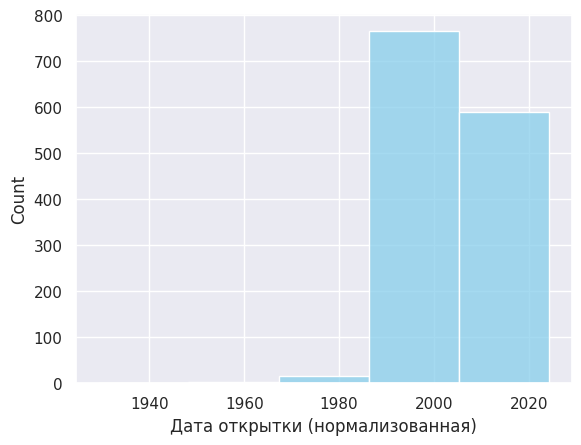

In [ ]:
sns.histplot(df_copy["Дата открытки (нормализованная)"], bins=5, kde=False, color='skyblue')

В датасете выявлены ошибки: постсоветская открытка датирована периодом до 1999 года. Подобные некорректные записи необходимо исключить из анализа.

In [ ]:
df_copy = df_copy[(df_copy['Дата открытки (нормализованная)'] >= '1991-12-26') | (df_copy['Дата открытки (нормализованная)'].isna())]

## Текст

Удалим наблюдение, если у него отсутствует текст.

In [ ]:
df_copy = df_copy[df_copy['Текст открытки'] != '[отсутствует]']

А также удалим тексты открыток с пропусками, так как они не будут применены в машинном обучении.

In [ ]:
full_df = df_copy[~df_copy['Текст открытки'].str.contains(r'\[нрзб\]', na=False)]
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1340 entries, 991 to 45738
Data columns (total 34 columns):
 #   Column                                                                                                                                                    Non-Null Count  Dtype         
---  ------                                                                                                                                                    --------------  -----         
 0   Номер открытки                                                                                                                                            1340 non-null   int64         
 1   Лицевая сторона - ссылка                                                                                                                                  1340 non-null   object        
 2   Оборотная сторона - ссылка                                                                                                        

In [ ]:
full_df.to_csv('full_df.csv', index=False)

## Длина текста

In [ ]:
text_lengths_chars = df_copy['Текст открытки'].apply(lambda x: len(str(x)))
mean_length_chars = text_lengths_chars.mean()
print(f"Средняя длина текста (в символах): {mean_length_chars:.2f}")

Средняя длина текста (в символах): 265.74


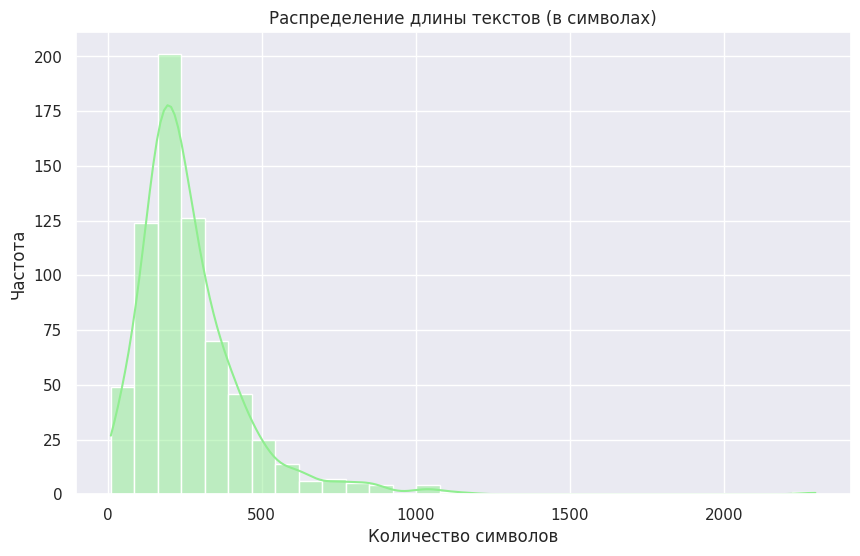

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(text_lengths_chars, bins=30, kde=True, color='lightgreen')
plt.title('Распределение длины текстов (в символах)')
plt.xlabel('Количество символов')
plt.ylabel('Частота')
plt.show()

Средняя длина текста 259 символов, даёт представление о типичном размере сообщения в открытке.

## Вывод

1. Данные были отфильтрованы на основании даты и языка открытки
2. Бли удалены открытки с пропущенными словами
3. Всего осталось 1340 объектов
4. Средняя длина текста открытки - 259 символов

# Решение проблемы классическим способом

## N-граммы

В генерации текста с помощью языковых моделей обычно выделяют три классических подхода:

1. Greedy Search (жадная генерация)

На каждом шаге выбирается самый вероятный следующий токен (буква или слово).

Генерация идёт по одному самому вероятному пути.

2. Beam Search (лучевой поиск)

На каждом шаге рассматривается несколько самых вероятных продолжений.

На каждом шаге сохраняются только beam width лучших путей, остальные отбрасываются.

3. Random Sampling (случайная генерация )

Следующий токен выбирается случайно, но с вероятностью, пропорциональной частоте/вероятности токена.

Позволяет генерировать более разнообразные тексты.

In [ ]:
!pip install nltk

In [ ]:
import nltk

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Предобработка текста и разделение данных

В рамках предобработки текста была выполнена очистка от всех символов, не относящихся к кириллическим буквам и пробельным символам, а также удалена пунктуация.

Все тексты приведены к нижнему регистру для унификации.

Лемматизация или приведение к начальной форме не применялись, чтобы сохранить исходную морфологическую структуру при предсказывании слова.

In [ ]:
def preprocess_text(text):
    text = re.sub(r'[^а-яА-ЯёЁ\s]', '', text)
    text = text.lower()  # Приводим к нижнему регистру
    text = re.sub(r'[^\w\s]', '', text)  # Удаляем пунктуацию
    return text

In [ ]:
# Разделение данных
from sklearn.model_selection import train_test_split
import re

train_texts, test_texts = train_test_split(full_df['Текст открытки'].apply(preprocess_text), test_size=0.2, random_state=42)
val_texts, test_texts = train_test_split(test_texts, test_size=0.5, random_state=42)

### Построение n-граммной модели

Создадим n-граммы и посчитаем их частоту.

In [ ]:
from nltk import ngrams, FreqDist

class NgramModel:
  def __init__(self, n, train_texts):
      self.n = n
      self.train_texts = train_texts
      self.ngrams = []
      self.freq = None

  def build_ngrams(self):
      texts = list(self.train_texts)
      for text in texts:
          tokens = text.split()
          self.ngrams.extend(list(ngrams(tokens, self.n)))
      self.freq = FreqDist(self.ngrams)

  def get_ngrams(self):
      return self.ngrams

  def get_freq(self):
      return self.freq

Посмотрим на триграммы исследуемого корпуса.

In [ ]:
trigram = NgramModel(n=3, train_texts=train_texts)

In [ ]:
trigram.build_ngrams()
trigram.get_ngrams()[:5]

[('с', 'новый', 'год'),
 ('новый', 'год', 'в'),
 ('год', 'в', 'новый'),
 ('в', 'новый', 'год'),
 ('новый', 'год', 'за')]

Создадим таблицу, где будут отражены оценки разных моделей.

In [ ]:
df_scores = pd.DataFrame(columns=['модель', 'параметры', 'accuracy'])

### GreedySearch

In [ ]:
import random
random.seed(42)

Создадим класс с жадным алгоритмом.

In [ ]:
class GreedySearch:
    def __init__(self, freq, n):
        """
        freq: FreqDist с n-граммами и их частотами
        n: размер n-граммы
        """
        self.freq = freq
        self.n = n

    def predict_next_word(self, context):
        """
        context: кортеж из n-1 слов
        Возвращает самое частотное следующее слово после context или None
        """
        candidates = {ngram[-1]: count for ngram, count in self.freq.items() if ngram[:-1] == context}
        if not candidates:
            return None
        return max(candidates, key=candidates.get)

    def generate_text(self, prompt, length=10):
        """
        prompt: начальная строка
        length: сколько слов сгенерировать
        Возвращает сгенерированный текст
        """
        tokens = prompt.split()
        for _ in range(length):
            if len(tokens) < self.n - 1:
                break
            context = tuple(tokens[-(self.n - 1):])
            next_word = self.predict_next_word(context)
            if not next_word:
                break
            tokens.append(next_word)
        return ' '.join(tokens)

    def evaluate_recovery(self, texts):
        """
        texts: список текстов для оценки
        Возвращает (correct, total, accuracy) по угадыванию пропущенного слова
        """
        total = 0
        correct = 0
        for text in texts:
            tokens = text.split()
            if len(tokens) < self.n:
                continue
            idx = random.randint(self.n - 1, len(tokens) - 1)
            context = tuple(tokens[idx - self.n + 1:idx])
            true_word = tokens[idx]
            predicted = self.predict_next_word(context)
            if predicted == true_word:
                correct += 1
            total += 1
        accuracy = correct / total if total else 0.0
        return correct, total, accuracy


Найдем лучший размер n-граммы.

In [ ]:
best_acc = 0
best_params = None

for n in [2, 3, 4]:
    ngram_model = NgramModel(n, train_texts)
    ngram_model.build_ngrams()
    model = GreedySearch(ngram_model.get_freq(), n=n)
    correct, total, acc = model.evaluate_recovery(val_texts)
    print(f"n={n} -> accuracy={acc:.2%}")
    if acc > best_acc:
        best_acc = acc
        best_params = (n, )

print(f"Лучшие параметры для жадного алгоритма: n={best_params[0]} с accuracy={best_acc:.2%}")

n=2 -> accuracy=16.42%
n=3 -> accuracy=14.93%
n=4 -> accuracy=11.19%
Лучшие параметры для жадного алгоритма: n=2 с accuracy=16.42%


Более высокую метрику жадный алгоритм показал, используя биграммную модель.

Оценим алгоритм на тестовых данных.

In [ ]:
ngram_model = NgramModel(2, train_texts)
ngram_model.build_ngrams()
best_model = GreedySearch(ngram_model.get_freq(), n=2)
correct, total, accuracy = model.evaluate_recovery(test_texts)

print(f"Тестовая оценка жадного алгоритма: Accuracy={accuracy:.2%}")

Тестовая оценка жадного алгоритма: Accuracy=9.02%


Достигнутая тестовая точность жадного алгоритма на уровне 9,02% свидетельствует о том, что модель способна предсказывать следующее слово с точностью выше случайного угадывания, однако её эффективность остаётся ограниченной.

In [ ]:
new_row = {
    'модель': 'GreedySearch',
    'параметры': 'n=2',
    'accuracy': '9.02%'
}

df_scores = pd.concat([df_scores, pd.DataFrame([new_row])], ignore_index=True)
df_scores

,модель,параметры,accuracy
0,GreedySearch,n=2,9.02%


### BeamSearch

Создадим класс с лучевым поиском.

In [ ]:
class BeamSearch:
    def __init__(self, freq, n, beam_width):
        """
        freq: FreqDist с n-граммами и их частотами
        n: размер n-граммы
        beam_width: ширина луча (количество рассматриваемых вариантов)
        """
        self.freq = freq
        self.n = n
        self.beam_width = beam_width

    def get_candidates(self, context):
        """
        context: кортеж из n-1 слов
        Возвращает список из (следующее_слово, частота), отсортированных по убыванию частоты,
        ограниченный beam_width
        """
        candidates = [(ngram[-1], count) for ngram, count in self.freq.items() if ngram[:-1] == context]
        candidates = sorted(candidates, key=lambda x: x[1], reverse=True)[:self.beam_width]
        return candidates

    def beam_search(self, prompt, length=10):
        """
        prompt: начальная строка
        length: сколько слов сгенерировать
        Возвращает сгенерированный текст
        """
        tokens = prompt.split()
        beams = [(tokens, 1.0)]  # (текущий путь, его score)

        for _ in range(length):
            all_candidates = []
            for seq, score in beams:
                if len(seq) < self.n - 1:
                    continue
                context = tuple(seq[-(self.n - 1):])
                candidates = self.get_candidates(context)
                if not candidates:
                    continue
                for next_word, cand_score in candidates:
                    new_seq = seq + [next_word]
                    new_score = score * cand_score  # можно использовать сумму логарифмов для стабильности
                    all_candidates.append((new_seq, new_score))
            if not all_candidates:
                break
            beams = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:self.beam_width]

        return ' '.join(beams[0][0]) if beams else prompt

    def evaluate_beam_recovery(self, texts):
        """
        texts: список текстов для оценки
        Возвращает (correct, total, accuracy) по угадыванию пропущенного слова
        """
        total = 0
        correct = 0

        for text in texts:
            tokens = text.split()
            if len(tokens) < self.n:
                continue
            idx = random.randint(self.n - 1, len(tokens) - 1)
            context = tuple(tokens[idx - self.n + 1:idx])
            true_word = tokens[idx]

            candidates = self.get_candidates(context)
            if not candidates:
                continue
            predicted_words = [word for word, _ in candidates]
            if true_word in predicted_words:
                correct += 1
            total += 1

        accuracy = correct / total if total else 0.0
        return correct, total, accuracy

Найдем лучшие параметры для этого алгоритма.

In [ ]:
best_acc = 0
best_params = None
for n in [2, 3, 4]:
    for beam_width in [2, 3, 5, 7]:
      ngram_model = NgramModel(n, train_texts)
      ngram_model.build_ngrams()
      model = BeamSearch(ngram_model.get_freq(), n=n, beam_width=beam_width)
      correct, total, acc = model.evaluate_beam_recovery(val_texts)
      print(f"n={n}, beam_width={beam_width} -> accuracy={acc:.2%}")
      if acc > best_acc:
          best_acc = acc
          best_params = (n, beam_width)

print(f"Лучшие параметры для лучевого поиска: n={best_params[0]}, beam_width={best_params[1]} с accuracy={best_acc:.2%}")

n=2, beam_width=2 -> accuracy=24.53%
n=2, beam_width=3 -> accuracy=30.58%
n=2, beam_width=5 -> accuracy=42.34%
n=2, beam_width=7 -> accuracy=36.13%
n=3, beam_width=2 -> accuracy=38.10%
n=3, beam_width=3 -> accuracy=38.71%
n=3, beam_width=5 -> accuracy=42.86%
n=3, beam_width=7 -> accuracy=41.67%
n=4, beam_width=2 -> accuracy=59.38%
n=4, beam_width=3 -> accuracy=51.35%
n=4, beam_width=5 -> accuracy=58.33%
n=4, beam_width=7 -> accuracy=58.62%
Лучшие параметры для лучевого поиска: n=4, beam_width=2 с accuracy=59.38%


Лучшие параметры означают, что модель учитывает контекст из четырёх слов и одновременно исследует два наиболее вероятных продолжения на каждом шаге генерации текста.

Оценим алгоритм на тестовой выборке.

In [ ]:
ngram_model = NgramModel(4, train_texts)
ngram_model.build_ngrams()
best_model = BeamSearch(ngram_model.get_freq(), n=4, beam_width=2)
correct, total, accuracy = model.evaluate_beam_recovery(test_texts)

print(f"Тестовая оценка лучевого поиска: Accuracy={accuracy:.2%}")

Тестовая оценка лучевого поиска: Accuracy=58.06%


Тестовая оценка лучевого поиска показывает значительное улучшение качества предсказания по сравнению с жадным поиском.

In [ ]:
new_row = {
    'модель': 'BeamSearch',
    'параметры': 'n=4, beam_width=2',
    'accuracy': '58.06%'
}

df_scores = pd.concat([df_scores, pd.DataFrame([new_row])], ignore_index=True)
df_scores

,модель,параметры,accuracy
0,GreedySearch,n=2,9.02%
1,BeamSearch,"n=4, beam_width=2",58.06%


### RandomSampler

Создадим класс с случайным алгоритмом.

In [ ]:
class RandomSampler:
    def __init__(self, freq, n=3, samples=5):
        """
        freq: FreqDist с n-граммами и их частотами
        n: размер n-граммы
        samples: количество случайных попыток при оценке восстановления
        """
        self.freq = freq
        self.n = n
        self.samples = samples

    def generate_text(self, prompt, length=10):
        """
        Генерация текста методом случайного сэмплинга
        prompt: начальная строка
        length: сколько слов сгенерировать
        """
        tokens = prompt.split()
        for _ in range(length):
            if len(tokens) < self.n - 1:
                break
            context = tuple(tokens[-(self.n - 1):])
            candidates = [(ngram[-1], count) for ngram, count in self.freq.items() if ngram[:-1] == context]
            if not candidates:
                break
            words, weights = zip(*candidates)
            next_word = random.choices(words, weights=weights)[0]
            tokens.append(next_word)
        return ' '.join(tokens)

    def evaluate_recovery(self, texts):
        """
        Оценка качества восстановления пропущенных слов
        texts: список текстов для оценки
        """
        total = 0
        correct = 0

        for text in texts:
            tokens = text.split()
            if len(tokens) < self.n:
                continue
            idx = random.randint(self.n - 1, len(tokens) - 1)
            context = tuple(tokens[idx - self.n + 1:idx])
            true_word = tokens[idx]
            candidates = [(ngram[-1], count) for ngram, count in self.freq.items() if ngram[:-1] == context]
            if not candidates:
                continue
            words, weights = zip(*candidates)
            guessed = False
            for _ in range(self.samples):
                predicted = random.choices(words, weights=weights)[0]
                if predicted == true_word:
                    guessed = True
                    break
            if guessed:
                correct += 1
            total += 1

        accuracy = correct / total if total else 0.0
        return correct, total, accuracy


Найдем лучшие параметры алгоритма.

In [ ]:
best_acc = 0
best_params = None

for n in [2, 3, 4]:
    for samples in [1, 3, 5, 7, 10]:
      ngram_model = NgramModel(n, train_texts)
      ngram_model.build_ngrams()
      model = RandomSampler(ngram_model.get_freq(), n=n, samples=samples)
      correct, total, acc = model.evaluate_recovery(val_texts)
      print(f"n={n}, samples={samples} -> accuracy={acc:.2%}")
      if acc > best_acc:
          best_acc = acc
          best_params = (n, samples)

print(f"Лучшие параметры для случайной генерации: n={best_params[0]}, samples={best_params[1]} с accuracy={best_acc:.2%}")

n=2, samples=1 -> accuracy=15.25%
n=2, samples=3 -> accuracy=15.18%
n=2, samples=5 -> accuracy=23.28%
n=2, samples=7 -> accuracy=24.32%
n=2, samples=10 -> accuracy=29.73%
n=3, samples=1 -> accuracy=38.57%
n=3, samples=3 -> accuracy=23.33%
n=3, samples=5 -> accuracy=43.94%
n=3, samples=7 -> accuracy=42.11%
n=3, samples=10 -> accuracy=53.70%
n=4, samples=1 -> accuracy=28.57%
n=4, samples=3 -> accuracy=29.17%
n=4, samples=5 -> accuracy=64.29%
n=4, samples=7 -> accuracy=57.14%
n=4, samples=10 -> accuracy=57.14%
Лучшие параметры для случайной генерации: n=4, samples=5 с accuracy=64.29%


Использование более длинного контекста (4-грамм) вместе с пятью случайными выборками следующего слова позволяет модели лучше предсказывать продолжение текста.

In [ ]:
ngram_model = NgramModel(4, train_texts)
ngram_model.build_ngrams()
best_model = RandomSampler(ngram_model.get_freq(), n=4, samples=5)
correct, total, accuracy = model.evaluate_recovery(test_texts)

print(f"Тестовая оценка случайного поиска: Accuracy={accuracy:.2%}")

Тестовая оценка случайного поиска: Accuracy=53.12%


Случайный поиск, несмотря на некоторую вариативность в выборе следующего слова, всё же улавливает определённые языковые закономерности, но предсказывает хуже, чем лучевой поиск.

In [ ]:
new_row = {
    'модель': 'RandomSampler',
    'параметры': 'n=4, samples=5',
    'accuracy': '53.12%'
}

df_scores = pd.concat([df_scores, pd.DataFrame([new_row])], ignore_index=True)
df_scores

,модель,параметры,accuracy
0,GreedySearch,n=2,9.02%
1,BeamSearch,"n=4, beam_width=2",58.06%
2,RandomSampler,"n=4, samples=5",53.12%


**Вывод: **

Жадный алгоритм хуже других алгоритмов справился с предсказанием слудующего слова, так как он опирается на частотные соотношение n-грамм и принимает локально оптимальные решения без учёта более широкого контекста.

Лучевой поиск показал самые высокие результаты. Он учитывает более широкий контекст и позволяет избегать ошибок, связанных с локально оптимальными, но глобально неоптимальными решениями.  

Случайный поиск имеет оценку выше, чем жадный алгоритм, поскольку учитывает несколько возможных вариантов развития текста, но из-за случайного выбора лучевой поиск оказывается лучше.


Пример использования лучевого поиска в тексте открыток.

In [ ]:
prompt = "с новым годом и"
beam_searcher = BeamSearch(ngram_model.get_freq(), n=4, beam_width=2)
generated_text = beam_searcher.beam_search(prompt, length=10)
print(generated_text)

с новым годом и рождеством христовым желаем крепкого здоровья счастья и долгих лет жизни


## Векторы

In [ ]:
!pip install gensim

In [ ]:
def preprocess_text(text):
    text = text.lower()
    # Удаляем все, кроме букв и пробелов
    text = re.sub(r'[^а-яёa-z\s]', '', text)
    # Разбиваем по пробелам
    tokens = text.split()
    return tokens

In [ ]:
full_df['tokens'] = full_df['Текст открытки'].apply(preprocess_text)

/tmp/ipython-input-42-3758122746.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_df['tokens'] = full_df['Текст открытки'].apply(preprocess_text)


In [ ]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd
import re


class Word2VecTrainer:
    def __init__(self, vector_size=100, window=5, min_count=2, epochs=5):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs
        self.model = None

    def train(self, sentences):
        self.model = Word2Vec(sentences=sentences,
                              vector_size=self.vector_size,
                              window=self.window,
                              min_count=self.min_count,
                              workers=4,
                              epochs=self.epochs)
        return self.model


class DatasetBuilder:
    def __init__(self, w2v_model, n=3):
        self.w2v_model = w2v_model
        self.n = n

    def make_dataset(self, texts):
        X, y = [], []
        w2v_vocab = set(self.w2v_model.wv.key_to_index.keys())

        for tokens in texts:
            if len(tokens) < self.n:
                continue
            for i in range(self.n - 1, len(tokens)):
                context = tokens[i - self.n + 1:i]
                target = tokens[i]
                if all(word in w2v_vocab for word in context) and target in w2v_vocab:
                    context_vec = np.mean([self.w2v_model.wv[word] for word in context], axis=0)
                    X.append(context_vec)
                    y.append(target)
        return np.array(X), np.array(y)


class NextWordPredictor:
    def __init__(self):
        self.label_encoder = LabelEncoder()
        self.classifier = LogisticRegression(max_iter=200, solver='liblinear')

    def train(self, X_train, y_train):
        y_train_enc = self.label_encoder.fit_transform(y_train)
        self.classifier.fit(X_train, y_train_enc)

    def evaluate(self, X, y):
        y_enc = self.label_encoder.transform(y)
        y_pred_enc = self.classifier.predict(X)
        acc = accuracy_score(y_enc, y_pred_enc)
        return acc

    def predict(self, context_vec):
        pred_enc = self.classifier.predict(context_vec.reshape(1, -1))[0]
        return self.label_encoder.inverse_transform([pred_enc])[0]


class HyperparameterTuner:
    def __init__(self, train_texts, val_texts):
        self.train_texts = train_texts
        self.val_texts = val_texts
        self.best_params = None
        self.best_val_acc = -1
        self.results = []

    def tune(self, vector_sizes, windows, epochs_list, ns):
        for vector_size in vector_sizes:
            for window in windows:
                for epochs in epochs_list:
                    for n in ns:
                        print(f"Тестируем: vector_size={vector_size}, window={window}, epochs={epochs}, n={n}")
                        # Обучаем Word2Vec
                        w2v_trainer = Word2VecTrainer(vector_size=vector_size, window=window, epochs=epochs)
                        w2v_model = w2v_trainer.train(self.train_texts)

                        # Создаем датасеты
                        dataset_builder = DatasetBuilder(w2v_model, n=n)
                        X_train, y_train = dataset_builder.make_dataset(self.train_texts)
                        X_val, y_val = dataset_builder.make_dataset(self.val_texts)

                        if len(X_train) == 0 or len(X_val) == 0:
                            print("  Недостаточно данных для обучения или валидации, пропускаем.")
                            continue

                        # Обучаем классификатор
                        predictor = NextWordPredictor()
                        predictor.train(X_train, y_train)

                        # Оцениваем на валидации
                        val_acc = predictor.evaluate(X_val, y_val)
                        print(f"  Validation accuracy: {val_acc:.4f}")

                        self.results.append({
                            'vector_size': vector_size,
                            'window': window,
                            'epochs': epochs,
                            'n': n,
                            'val_accuracy': val_acc
                        })

                        if val_acc > self.best_val_acc:
                            self.best_val_acc = val_acc
                            self.best_params = {
                                'vector_size': vector_size,
                                'window': window,
                                'epochs': epochs,
                                'n': n
                            }

    def get_best_params(self):
        return self.best_params

    def get_results_df(self):
        return pd.DataFrame(self.results)

In [ ]:
tuner = HyperparameterTuner(train_texts, val_texts)
tuner.tune(
    vector_sizes=[50, 100],
    windows=[3, 5],
    epochs_list=[5, 10],
    ns=[2, 3]
)

best_params = tuner.get_best_params()
best_params

Тестируем: vector_size=50, window=3, epochs=5, n=2
Validation accuracy: 0.2572
Тестируем: vector_size=50, window=3, epochs=5, n=3
Validation accuracy: 0.2333
Тестируем: vector_size=50, window=3, epochs=10, n=2


Параметры Word2Vec:

vector_size=50 — размерность векторного представления каждого слова.

window=3 — размер контекстного окна, то есть сколько слов слева и справа учитывается при обучении.  

epochs=5 — количество проходов по всему корпусу данных.

n=2 — количество слов для генерации  

Обучим финальную модель.

In [ ]:
w2v_trainer = Word2VecTrainer(
    vector_size=50,
    window=3,
    epochs=5
)
final_w2v_model = w2v_trainer.train(train_texts)

dataset_builder = DatasetBuilder(final_w2v_model, n=2)
X_train_full, y_train_full = dataset_builder.make_dataset(train_texts)
X_test, y_test = dataset_builder.make_dataset(test_texts)

predictor = NextWordPredictor()
predictor.train(X_train_full, y_train_full)
test_acc = predictor.evaluate(X_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.2615


**Вывод:** Модель имеет низкую точность. Значение 26% говорит о том, что модель пока плохо справляется с задачей и часто ошибается. Возможно, стоит провести лемматизацию текста, увеличить количество эпох и/или изменить параметры модели (размер векторов, окно и т.п.).

In [ ]:
new_row = {
    'модель': 'Word2VecTrainer',
    'параметры': 'vector_size=50, window=3, epochs=5',
    'accuracy': '26%'
}

df_scores = pd.concat([df_scores, pd.DataFrame([new_row])], ignore_index=True)
df_scores

,модель,параметры,accuracy
0,GreedySearch,n=2,9.02%
1,BeamSearch,"n=4, beam_width=2",58.06%
2,RandomSampler,"n=4, samples=5",53.12%
3,Word2VecTrainer,"vector_size=50, window=3, epochs=5",26%


## Вывод

Таким образом, среди рассмотренных методов для задачи предсказания слова лучшую точность показывает BeamSearch с шириной луча 2 и длиной последовательности 4. Методы на основе случайного сэмплирования дают чуть меньший результат, а жадный поиск — самый низкий.

Word2Vec полезен для построения семантических представлений, но для генерации текста требует дополнительной обработки и дообучения.

# Решение проблемы алгоритмом Deep Learning

При построении обычной модели LSTM мы получали оцень низкую оценку, поэтому мы решили немного улучшить ее структуру:

1. Ограничен словарь max_words=10000 — мы взяли только 10 тысяч самых популярных слов, чтобы модель не путалась и работала быстрее.

2. Добавлен токен < OOV > — это специальное слово для всех редких или незнакомых слов, которые не вошли в 10 тысяч.

3. Паддинг сделан в конец (padding='post') — короткие предложения дополняются пустыми местами в конце, так модели проще понять последовательность слов.

4. Увеличен размер эмбеддинга и LSTM слоя — модель стала "умнее" и может лучше запоминать и обрабатывать информацию.

5. Добавлен Dropout для регуляризации — чтобы vjltkm не запоминала данные слишком буквально и лучше училась на новых примерах.

6. Добавлен EarlyStopping — обучение останавливается заранее, если модель перестаёт улучшаться, чтобы не тратить время и не переобучиться.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import re

In [ ]:
full_df['clean_text'] = full_df['Текст открытки'].apply(preprocess_text)

Проведем токенизацию с ограниченным размером словаря

In [ ]:
texts = full_df['clean_text'].tolist()
max_words = 10000  # Ограничиваем словарь топ-10000 словами
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
total_words = max_words  # Используем ограниченный словарь

Создадим последовательности для обучения

In [ ]:
input_sequences = []

for line in texts:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

Паддинг последовательностей

In [ ]:
max_seq_len = 259
input_sequences = pad_sequences(input_sequences, maxlen=max_seq_len, padding='post')

Разделим на X и y и преобразуем в one-hot encoding

In [ ]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = to_categorical(y, num_classes=total_words)

Разделение данных

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42)  # 0.125*0.8=0.1

print(f"Train samples: {len(X_train)}, Val samples: {len(X_val)}, Test samples: {len(X_test)}")

Train samples: 33435, Val samples: 4777, Test samples: 9554


Построение модели LSTM с Dropout

In [ ]:
model = Sequential()
model.add(Embedding(total_words, 200, input_length=max_seq_len - 1))
model.add(LSTM(256, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(total_words, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Обучение модели с EarlyStopping

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=2,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/2
523/523 ━━━━━━━━━━━━━━━━━━━━ 1391s 3s/step - accuracy: 0.9869 - loss: 0.9063 - val_accuracy: 1.0000 - val_loss: 2.6961e-04
Epoch 2/2
523/523 ━━━━━━━━━━━━━━━━━━━━ 1369s 3s/step - accuracy: 1.0000 - loss: 7.0946e-04 - val_accuracy: 1.0000 - val_loss: 1.3446e-04


Оценим на тесте

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

299/299 ━━━━━━━━━━━━━━━━━━━━ 129s 430ms/step - accuracy: 1.0000 - loss: 1.3446e-04
Test accuracy: 1.0000


Сохраним модель

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/my_lstm_model.keras')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 204, 200)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       467,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10000)          │     2,570,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,113,906 (57.65 MB)

 Trainable params: 5,037,968 (19.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,075,938 (38.44 MB)

Пример использования

In [ ]:
def predict_next_word(model, tokenizer, text, max_seq_len):
    text = preprocess_text(text)
    token_list = tokenizer.texts_to_sequences([text])[0]
    token_list = pad_sequences([token_list], maxlen=max_seq_len - 1, padding='post')

    predicted = model.predict(token_list, verbose=0)

    # Получаем индексы слов и их вероятности
    predicted_indices = np.argsort(predicted[0])[::-1]  # Сортируем по убыванию
    top_two_indices = predicted_indices[:10]  # Берем первые два индекса

    # Получаем слова по индексам
    predicted_words = [tokenizer.index_word.get(idx, None) for idx in top_two_indices]
    for word in predicted_words:
      if word:
        return top_two_indices[1], word

context = "с новым"
word_index, next_word = predict_next_word(model, tokenizer, context, max_seq_len)
print(f"Следующее слово после '{context}': {next_word}")

Следующее слово после 'с новым': христовым


In [ ]:
new_row = {
    'модель': 'LSTM',
    'параметры': 'embedding=200, lstm_units=256, dropout=0.2, recurrent_dropout=0.2, epochs=2, batch_size=64, optimizer=adam',
    'accuracy': '100%'
}

df_scores = pd.concat([df_scores, pd.DataFrame([new_row])], ignore_index=True)
df_scores

,модель,параметры,accuracy
0,GreedySearch,n=2,9.02%
1,BeamSearch,"n=4, beam_width=2",58.06%
2,RandomSampler,"n=4, samples=5",53.12%
3,Word2VecTrainer,"vector_size=50, window=3, epochs=5",26%
4,LSTM,"embedding=200, lstm_units=256, dropout=0.2, re...",100%


**Вывод:**
Несмотря на очень высокую точность обучения и тестирования (accuracy 100%), модель демонстрирует странные и не всегда осмысленные примеры заполнения слов. Возможно, модель переобучилась или нужно немного поменять архитектуру.  

# Решение проблемы SOTA-алгоритмом

Загрузим обученную модель и дообучим ее на наших данных.

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, DataCollatorForLanguageModeling, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split

# Подготовка данных, разделение на train, test, val
texts = df_copy['Текст открытки'].dropna().tolist()
train_texts, temp_texts = train_test_split(texts, test_size=0.2, random_state=42)
val_texts, test_texts = train_test_split(temp_texts, test_size=0.5, random_state=42)

train_dataset = Dataset.from_dict({"text": train_texts})
val_dataset = Dataset.from_dict({"text": val_texts})

# Загрузка токенизатора и модели ruRoberta
model_name = "ai-forever/ruRoberta-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)

# Токенизация
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=256)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=True, mlm_probability=0.15
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/674 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Map:   0%|          | 0/546 [00:00<?, ? examples/s]

Map:   0%|          | 0/68 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Вычисление loss (кросс-энтропийной) происходит внутри Trainer => здесь можно возвращать метрики, если есть
    predictions = np.argmax(logits, axis=-1)
    # Для masked language modeling можно вычислить accuracy по предсказанным токенам, игнорируя -100
    mask = labels != -100
    correct = (predictions == labels)[mask]
    accuracy = np.sum(correct) / np.sum(mask) if np.sum(mask) > 0 else 0.0
    return {
        'masked_lm_accuracy': accuracy
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./ruRoberta-finetuned",
    report_to="none",
    learning_rate=2e-5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=3,
    num_train_epochs=2,
    weight_decay=0.01,
    save_total_limit=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Запуск дообучения
trainer.train()

Step,Training Loss
500,1.860700
1000,1.631600


TrainOutput(global_step=1092, training_loss=1.7202887622428027, metrics={'train_runtime': 681.364, 'train_samples_per_second': 1.603, 'train_steps_per_second': 1.603, 'total_flos': 508918831110144.0, 'train_loss': 1.7202887622428027, 'epoch': 2.0})

In [ ]:
# Сохранение модели
model.save_pretrained("./ruRoberta-finetuned")

# Сохранение токенизатора
tokenizer.save_pretrained("./ruRoberta-finetuned")

('./ruRoberta-finetuned/tokenizer_config.json',
 './ruRoberta-finetuned/special_tokens_map.json',
 './ruRoberta-finetuned/vocab.json',
 './ruRoberta-finetuned/merges.txt',
 './ruRoberta-finetuned/added_tokens.json',
 './ruRoberta-finetuned/tokenizer.json')

Оценка на валидационных данных

In [ ]:
# После обучения можно вызвать evaluate, чтобы получить оценку на валидации:
metrics = trainer.evaluate()
print(metrics)

{'eval_loss': 1.9776164293289185, 'eval_masked_lm_accuracy': 0.6048265460030166, 'eval_runtime': 11.6942, 'eval_samples_per_second': 5.815, 'eval_steps_per_second': 1.967, 'epoch': 2.0}


Оценка на тестовых данных

In [ ]:
test_dataset = Dataset.from_dict({"text": test_texts})
tokenized_test = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/69 [00:00<?, ? examples/s]

In [ ]:
metrics = trainer.evaluate(eval_dataset=tokenized_test)
print(metrics)

{'eval_loss': 1.674919843673706, 'eval_masked_lm_accuracy': 0.6960629921259842, 'eval_runtime': 7.7499, 'eval_samples_per_second': 8.903, 'eval_steps_per_second': 2.968, 'epoch': 2.0}


In [ ]:
new_row = {
    'модель': 'ruRoberta-large (SOTA)',
    'параметры': '',
    'accuracy': '69.6%'
}

df_scores = pd.concat([df_scores, pd.DataFrame([new_row])], ignore_index=True)

df_scores


,модель,параметры,accuracy
0,GreedySearch,n=2,9.02%
1,BeamSearch,"n=4, beam_width=2",58.06%
2,RandomSampler,"n=4, samples=5",53.12%
3,Word2VecTrainer,"vector_size=50, window=3, epochs=5",26%
4,LSTM,"embedding=200, lstm_units=256, dropout=0.2, re...",100%
5,ruRoberta-large (SOTA),,69.6%


**Вывод:**  

Оценка на тесте с такими метриками — это достаточно хороший результат, особенно для задачи masked language modeling (MLM) на русском языке.

eval_loss = 1.6749 — значение функции потерь сравнительно невысокое, что указывает на то, что модель хорошо предсказывает замаскированные токены.

eval_masked_lm_accuracy = 0.6961 (около 69.6%) — точность предсказания замаскированных слов близка к 70%, для сложной задачи восстановления слов по контексту является хорошим показателем.  

Таким образом, текущие показатели свидетельствуют о корректной и достаточно качественной работе модели на тестовом наборе данных

# Работа Sota-алгоритма на реальных пропусках

In [ ]:
from transformers import pipeline

In [ ]:
# Создаём pipeline для заполнения пропусков
pipe = pipeline(
    "fill-mask",
    model=model,
    tokenizer=tokenizer,
    top_k=5  # сколько вариантов предсказаний показывать
)

Device set to use cuda:0


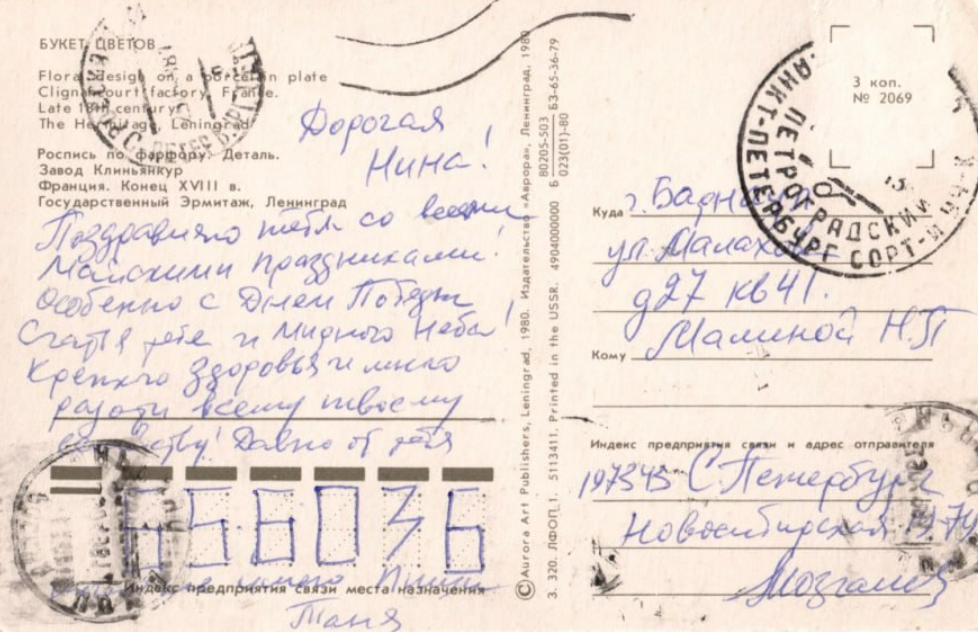

In [ ]:
text = (
    "Дорогая Нина! Поздравляю тебя со всеми майскими праздниками! Особенно с Днем Победы. Счастья тебе и мирного неба!\n"
    "Крепкого здоровья и много радости всему твоему семейству! Давно от тебя <mask> Пиши Таня"
)
results = pipe(text)
for r in results:
    print(r['sequence'], r['score'])

Дорогая Нина! Поздравляю тебя со всеми майскими праздниками! Особенно с Днем Победы. Счастья тебе и мирного неба!
Крепкого здоровья и много радости всему твоему семейству! Давно от тебя. Пиши Таня 0.2355033904314041
Дорогая Нина! Поздравляю тебя со всеми майскими праздниками! Особенно с Днем Победы. Счастья тебе и мирного неба!
Крепкого здоровья и много радости всему твоему семейству! Давно от тебя жду Пиши Таня 0.2131785899400711
Дорогая Нина! Поздравляю тебя со всеми майскими праздниками! Особенно с Днем Победы. Счастья тебе и мирного неба!
Крепкого здоровья и много радости всему твоему семейству! Давно от тебя! Пиши Таня 0.20520372688770294
Дорогая Нина! Поздравляю тебя со всеми майскими праздниками! Особенно с Днем Победы. Счастья тебе и мирного неба!
Крепкого здоровья и много радости всему твоему семейству! Давно от тебя ждала Пиши Таня 0.05846426635980606
Дорогая Нина! Поздравляю тебя со всеми майскими праздниками! Особенно с Днем Победы. Счастья тебе и мирного неба!
Крепкого здо

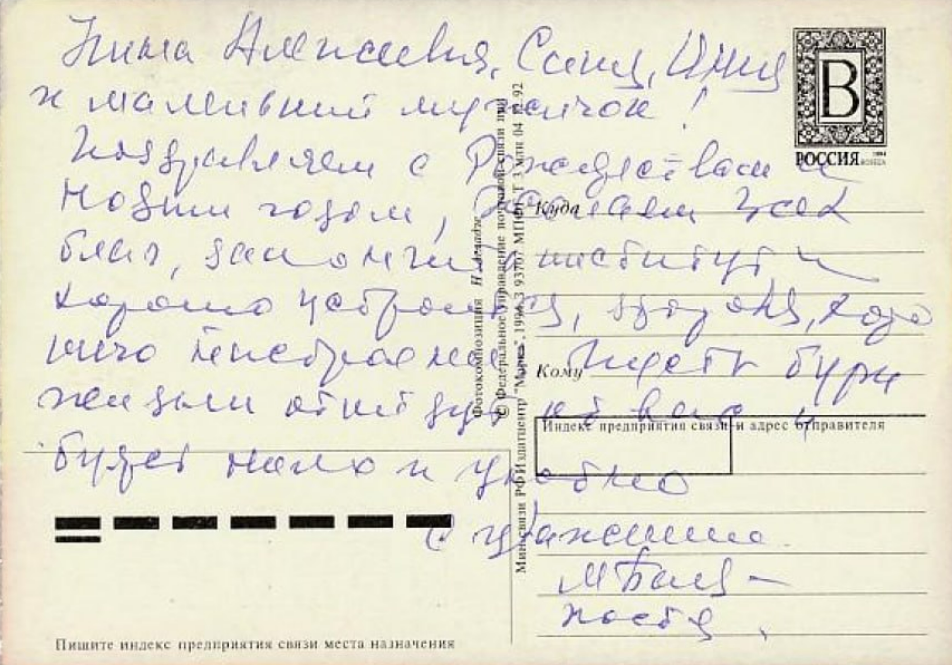

In [ ]:
text = (
    "Нина Алексеевна, Саня, Инна и маленький мужичок! Поздравляем с Рождеством и с Новым годом, Желаем всех благ, закончить институт и хорошо устроиться, здоровья, хорошего настроения\n"
    "Пусть бури жизни <mask> об вас и будет мило и удобно С уважением <подпись> Костя."
)
results = pipe(text)
for r in results:
    print(r['sequence'], r['score'])

Нина Алексеевна, Саня, Инна и маленький мужичок! Поздравляем с Рождеством и с Новым годом, Желаем всех благ, закончить институт и хорошо устроиться, здоровья, хорошего настроения
Пусть бури жизни говорят об вас и будет мило и удобно С уважением <подпись> Костя. 0.2187495082616806
Нина Алексеевна, Саня, Инна и маленький мужичок! Поздравляем с Рождеством и с Новым годом, Желаем всех благ, закончить институт и хорошо устроиться, здоровья, хорошего настроения
Пусть бури жизни пройдут об вас и будет мило и удобно С уважением <подпись> Костя. 0.20971253514289856
Нина Алексеевна, Саня, Инна и маленький мужичок! Поздравляем с Рождеством и с Новым годом, Желаем всех благ, закончить институт и хорошо устроиться, здоровья, хорошего настроения
Пусть бури жизни скажут об вас и будет мило и удобно С уважением <подпись> Костя. 0.08794339001178741
Нина Алексеевна, Саня, Инна и маленький мужичок! Поздравляем с Рождеством и с Новым годом, Желаем всех благ, закончить институт и хорошо устроиться, здоровь

# Итог

В целом, задача предсказания слова может быть решена как классическими методами, так и глубоким обучением. Однако для достижения высокого качества результатов необходимо тщательно обучать модели и подбирать гиперпараметры. Улучшение архитектуры, увеличение объёма данных и более длительное обучение могут значительно повысить качество предсказаний и приблизить модель к уровню SOTA.